# Step 02 — Download Labels (BSISO Phase + ENSO Category)
**Project:** ENSO-BSISO Self-Supervised Learning  
**Author:** Jiayi (jh9141@nyu.edu)

This notebook downloads the two label sources for our project:
- **BSISO phase (1–8):** Daily index from APEC Climate Center (Lee et al. 2013)
- **ENSO category:** NOAA Niño 3.4 JJA mean → El Niño / Neutral / La Niña

**Output:** `BSISO_SSL_Project/data/raw/labels.csv`  
Columns: `date`, `bsiso_phase`, `bsiso_amplitude`, `nino34_jja`, `enso_category`

---

## ⚠️ Before Running — Download BSISO Index Manually

The APEC BSISO index requires a manual download step:

1. Go to **http://www.apcc21.org/ser/moni.do?lang=en**
2. Find the **Historical BSISO Index** download link
3. Download the text file (usually named something like `BSISO_INDEX.txt`)
4. Upload it to your Google Drive at:
   ```
   BSISO_SSL_Project/data/raw/BSISO_INDEX.txt
   ```
   (In Google Drive: navigate to the folder → New → File upload)

The NOAA ENSO data is downloaded automatically in Cell 5.

---

## Cell 1 — Mount Google Drive + Setup

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

PROJECT_DIR = '/content/drive/MyDrive/BSISO_SSL_Project'
RAW_DIR = f'{PROJECT_DIR}/data/raw'

print('Google Drive mounted.')
print(f'Raw data folder: {RAW_DIR}')
print('Files currently in raw/:')
for f in sorted(os.listdir(RAW_DIR)):
    mb = os.path.getsize(f'{RAW_DIR}/{f}') / 1e6
    print(f'  {f}  ({mb:.1f} MB)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Raw data folder: /content/drive/MyDrive/BSISO_SSL_Project/data/raw
Files currently in raw/:
  BSISO.INDEX.NORM.LY.data  (1.1 MB)
  OLR_July_1979_2023.nc  (4.8 MB)
  u850_v850_July_1979_1989.nc  (2.9 MB)
  u850_v850_July_1990_1999.nc  (2.7 MB)
  u850_v850_July_2000_2009.nc  (2.7 MB)
  u850_v850_July_2010_2019.nc  (2.7 MB)
  u850_v850_July_2020_2023.nc  (1.1 MB)


## Cell 2 — Load and Parse BSISO Index

Reads the BSISO index file you uploaded to Google Drive.  
The APEC BSISO index file has these columns:  
`year  month  day  PC1_BSISO1  PC2_BSISO1  phase  amplitude  PC1_BSISO2  PC2_BSISO2  phase2  amplitude2`

We only need: **date**, **phase (1–8)**, **amplitude** from BSISO1.

In [14]:
bsiso_path = f'{RAW_DIR}/BSISO.INDEX.NORM.LY.data'

if not os.path.exists(bsiso_path):
    print('ERROR: BSISO_INDEX.txt not found!')
    print(f'Please upload it to: {RAW_DIR}/')
    print('See the instructions in the title cell above.')
else:
    # Preview the first few raw lines to understand format
    print('First 5 lines of raw file:')
    with open(bsiso_path, 'r') as f:
        for i, line in enumerate(f):
            print(f'  {repr(line.rstrip())}')
            if i >= 4:
                break

First 5 lines of raw file:
  ' YEAR  DAY  BSISO1-1 BSISO1-2 BSISO2-1 BSISO2-2 BSISO1  BSISO2'
  '  1981   1    0.437   -0.020    0.716    0.159    0.437    0.733'
  '  1981   2    0.523    0.295    0.881    0.117    0.600    0.889'
  '  1981   3    0.070    0.494    0.409    0.404    0.499    0.575'
  '  1981   4   -0.267    0.195    0.285    0.292    0.330    0.408'


## Cell 3 — Parse BSISO Index into DataFrame

Run Cell 2 first and check the format, then run this cell.  
If the column order in your file looks different, adjust `col_names` below.

In [15]:
# File format: YEAR  DOY  BSISO1-1  BSISO1-2  BSISO2-1  BSISO2-2  BSISO1_amp  BSISO2_amp
# DOY = day of year (1-365/366), NOT day of month
# No phase column — compute from PC1/PC2 via atan2

rows = []
with open(bsiso_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line[0].isalpha() or line.startswith('#'):
            continue
        parts = line.split()
        if len(parts) >= 7:
            rows.append(parts)

col_names = ['year', 'doy', 'pc1_bsiso1', 'pc2_bsiso1',
             'pc1_bsiso2', 'pc2_bsiso2', 'bsiso1_amp', 'bsiso2_amp']
df_bsiso = pd.DataFrame(rows, columns=col_names[:len(rows[0])])

# Convert types
df_bsiso['year']       = df_bsiso['year'].astype(int)
df_bsiso['doy']        = df_bsiso['doy'].astype(int)
df_bsiso['pc1_bsiso1'] = df_bsiso['pc1_bsiso1'].astype(float)
df_bsiso['pc2_bsiso1'] = df_bsiso['pc2_bsiso1'].astype(float)
df_bsiso['bsiso1_amp'] = df_bsiso['bsiso1_amp'].astype(float)

# Convert year + day-of-year → calendar date
df_bsiso['date'] = pd.to_datetime(
    df_bsiso['year'].astype(str) + df_bsiso['doy'].astype(str).str.zfill(3),
    format='%Y%j'
)

# Compute BSISO1 phase (1–8) from PC1 and PC2 using atan2
# Divide the PC1-PC2 plane into 8 equal 45° sectors
angle = np.degrees(np.arctan2(df_bsiso['pc2_bsiso1'], df_bsiso['pc1_bsiso1']))
angle = (angle + 360) % 360  # map to 0–360
df_bsiso['bsiso_phase']     = (np.floor(angle / 45).astype(int) % 8) + 1
df_bsiso['bsiso_amplitude'] = df_bsiso['bsiso1_amp']

print(f'Total BSISO records: {len(df_bsiso)}')
print(f'Date range: {df_bsiso["date"].min().date()} to {df_bsiso["date"].max().date()}')
print(f'\nPhase distribution:')
print(df_bsiso['bsiso_phase'].value_counts().sort_index())
print()
print(df_bsiso[['date', 'bsiso_phase', 'bsiso_amplitude']].head(10))

Total BSISO records: 16375
Date range: 1981-01-01 to 2025-10-31

Phase distribution:
bsiso_phase
1    2121
2    2222
3    2271
4    1737
5    1939
6    2055
7    1931
8    2099
Name: count, dtype: int64

        date  bsiso_phase  bsiso_amplitude
0 1981-01-01            8            0.437
1 1981-01-02            1            0.600
2 1981-01-03            2            0.499
3 1981-01-04            4            0.330
4 1981-01-05            3            0.609
5 1981-01-06            3            0.867
6 1981-01-07            3            0.857
7 1981-01-08            3            0.783
8 1981-01-09            3            1.089
9 1981-01-10            2            1.042


## Cell 4 — Filter BSISO to July 1979–2023

In [16]:
# Keep only MJJAS (months 5-9), years 1979-2023
MJJAS_MONTHS = [5, 6, 7, 8, 9]

df_mjjas_bsiso = df_bsiso[
    (df_bsiso['date'].dt.month.isin(MJJAS_MONTHS)) &
    (df_bsiso['date'].dt.year >= 1979) &
    (df_bsiso['date'].dt.year <= 2023)
].copy()

df_mjjas_bsiso = df_mjjas_bsiso[['date', 'bsiso_phase', 'bsiso_amplitude']].reset_index(drop=True)

print(f'MJJAS BSISO records (1979-2023): {len(df_mjjas_bsiso)}')
print(f'Expected: ~{45 * 153} (45 years × ~153 days)')
print(f'\nPhase distribution (MJJAS):')
print(df_mjjas_bsiso['bsiso_phase'].value_counts().sort_index())
print(f'\nMonth distribution:')
print(df_mjjas_bsiso['date'].dt.month.value_counts().sort_index())
print()
print(df_mjjas_bsiso.head())

July BSISO records (1979-2023): 1333
Expected: ~1395 (45 years × 31 days)

Phase distribution (July only):
bsiso_phase
1    192
2    184
3    195
4    125
5    135
6    169
7    134
8    199
Name: count, dtype: int64

        date  bsiso_phase  bsiso_amplitude
0 1981-07-01            3            0.845
1 1981-07-02            3            1.181
2 1981-07-03            3            1.140
3 1981-07-04            3            1.292
4 1981-07-05            3            1.359


## Cell 5 — Download NOAA Niño 3.4 Monthly Index

Downloads monthly Niño 3.4 SST anomaly from NOAA CPC (ERSST5, 1991–2020 baseline).  
We compute the **JJA mean** (June–July–August) for each year to classify ENSO.

In [17]:
import requests

nino_url = 'https://www.cpc.ncep.noaa.gov/data/indices/ersst5.nino.mth.91-20.ascii'
nino_path = f'{RAW_DIR}/nino34_monthly.txt'

if os.path.exists(nino_path):
    print(f'File already exists, skipping download: {nino_path}')
else:
    print(f'Downloading Niño 3.4 index from NOAA CPC...')
    response = requests.get(nino_url, timeout=30)
    response.raise_for_status()
    with open(nino_path, 'w') as f:
        f.write(response.text)
    print(f'Saved to: {nino_path}')

# Preview raw file
print('\nFirst 5 lines:')
with open(nino_path, 'r') as f:
    for i, line in enumerate(f):
        print(f'  {line.rstrip()}')
        if i >= 4:
            break

Saved to: /content/drive/MyDrive/BSISO_SSL_Project/data/raw/nino34_monthly.txt

First 5 lines:
   YR   MON  NINO1+2  ANOM   NINO3    ANOM   NINO4    ANOM   NINO3.4  ANOM
  1950   1   23.01   -1.55   23.56   -2.10   26.94   -1.38   24.55   -1.99
  1950   2   24.32   -1.78   24.89   -1.52   26.67   -1.53   25.06   -1.69
  1950   3   25.11   -1.38   26.36   -0.84   26.52   -1.80   25.87   -1.42
  1950   4   23.63   -1.90   26.44   -1.14   26.90   -1.73   26.28   -1.54


## Cell 6 — Parse Niño 3.4 and Compute JJA Mean ENSO Category

ENSO classification thresholds (standard NOAA definition):  
- **El Niño:** JJA Niño 3.4 anomaly ≥ +0.5°C  
- **La Niña:** JJA Niño 3.4 anomaly ≤ −0.5°C  
- **Neutral:** between −0.5 and +0.5°C

In [18]:
# Parse NOAA CPC Nino file
# Format: YR  MON  NINO1+2  ANOM  NINO3  ANOM  NINO4  ANOM  NINO3.4  ANOM
# Columns:  0    1      2     3      4     5      6     7       8      9

rows = []
with open(nino_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('YR') or line[0].isalpha():
            continue
        parts = line.split()
        if len(parts) >= 10:
            try:
                rows.append({
                    'year':  int(parts[0]),
                    'month': int(parts[1]),
                    'nino34_anom': float(parts[9])  # Nino3.4 anomaly column
                })
            except ValueError:
                continue

df_nino = pd.DataFrame(rows)
print(f'Monthly Nino3.4 records: {len(df_nino)}')
print(f'Year range: {df_nino["year"].min()} – {df_nino["year"].max()}')

# Compute JJA mean (months 6, 7, 8) per year
df_jja = df_nino[df_nino['month'].isin([6, 7, 8])].groupby('year')['nino34_anom'].mean().reset_index()
df_jja.columns = ['year', 'nino34_jja']

# Classify ENSO
def classify_enso(val):
    if val >= 0.5:
        return 'El Nino'
    elif val <= -0.5:
        return 'La Nina'
    else:
        return 'Neutral'

df_jja['enso_category'] = df_jja['nino34_jja'].apply(classify_enso)

# Filter to 1979-2023
df_jja = df_jja[(df_jja['year'] >= 1979) & (df_jja['year'] <= 2023)].reset_index(drop=True)

print(f'\nJJA Nino3.4 for 1979-2023 ({len(df_jja)} years):')
print(df_jja['enso_category'].value_counts())
print()
print(df_jja.head(10))

Monthly Nino3.4 records: 914
Year range: 1950 – 2026

JJA Nino3.4 for 1979-2023 (45 years):
enso_category
Neutral    27
La Nina    11
El Nino     7
Name: count, dtype: int64

   year  nino34_jja enso_category
0  1979   -0.286667       Neutral
1  1980   -0.076667       Neutral
2  1981   -0.543333       La Nina
3  1982    0.543333       El Nino
4  1983    0.053333       Neutral
5  1984   -0.546667       La Nina
6  1985   -0.736667       La Nina
7  1986   -0.033333       Neutral
8  1987    1.260000       El Nino
9  1988   -1.556667       La Nina


## Cell 7 — Merge BSISO + ENSO → labels.csv

In [19]:
# Add year column to BSISO for merging
df_mjjas_bsiso['year'] = df_mjjas_bsiso['date'].dt.year

# Merge on year — ENSO JJA category applied to all MJJAS days in that year
df_labels = df_mjjas_bsiso.merge(df_jja[['year', 'nino34_jja', 'enso_category']], on='year', how='left')

# Check for any missing ENSO values
n_missing = df_labels['enso_category'].isna().sum()
if n_missing > 0:
    print(f'WARNING: {n_missing} rows have missing ENSO category (years not in NOAA data)')
    print(df_labels[df_labels['enso_category'].isna()]['year'].unique())
else:
    print('All rows have ENSO category assigned.')

# Final column order
df_labels = df_labels[['date', 'bsiso_phase', 'bsiso_amplitude', 'nino34_jja', 'enso_category']]

# Save to CSV
labels_path = f'{RAW_DIR}/labels_mjjas.csv'
df_labels.to_csv(labels_path, index=False)
print(f'\nSaved: {labels_path}')
print(f'Total rows: {len(df_labels)}')
print()
print(df_labels.head(10))

All rows have ENSO category assigned.

Saved: /content/drive/MyDrive/BSISO_SSL_Project/data/raw/labels.csv
Total rows: 1333

        date  bsiso_phase  bsiso_amplitude  nino34_jja enso_category
0 1981-07-01            3            0.845   -0.543333       La Nina
1 1981-07-02            3            1.181   -0.543333       La Nina
2 1981-07-03            3            1.140   -0.543333       La Nina
3 1981-07-04            3            1.292   -0.543333       La Nina
4 1981-07-05            3            1.359   -0.543333       La Nina
5 1981-07-06            3            1.162   -0.543333       La Nina
6 1981-07-07            3            1.018   -0.543333       La Nina
7 1981-07-08            3            1.142   -0.543333       La Nina
8 1981-07-09            3            0.787   -0.543333       La Nina
9 1981-07-10            3            0.112   -0.543333       La Nina


## Cell 8 — Verification Report

LABELS VERIFICATION REPORT
Total July days:   1333
Date range:        1981-07-01 to 2023-07-31
Missing values:    0

BSISO Phase distribution:
  Phase 1: 192 days
  Phase 2: 184 days
  Phase 3: 195 days
  Phase 4: 125 days
  Phase 5: 135 days
  Phase 6: 169 days
  Phase 7: 134 days
  Phase 8: 199 days

ENSO Category distribution:
  Neutral: 775 days (58.1%)
  La Nina: 341 days (25.6%)
  El Nino: 217 days (16.3%)

Phase × ENSO sample counts (rows=phase, cols=ENSO):
enso_category  El Nino  La Nina  Neutral
bsiso_phase                             
1                   31       39      122
2                   31       35      118
3                   36       41      118
4                   20       27       78
5                   32       25       78
6                   33       35      101
7                   11       65       58
8                   23       74      102

(These are the bins the model will learn from — check no bin is empty!)

FILE ON GOOGLE DRIVE:
  ✓ labels.csv  (0.06 MB)

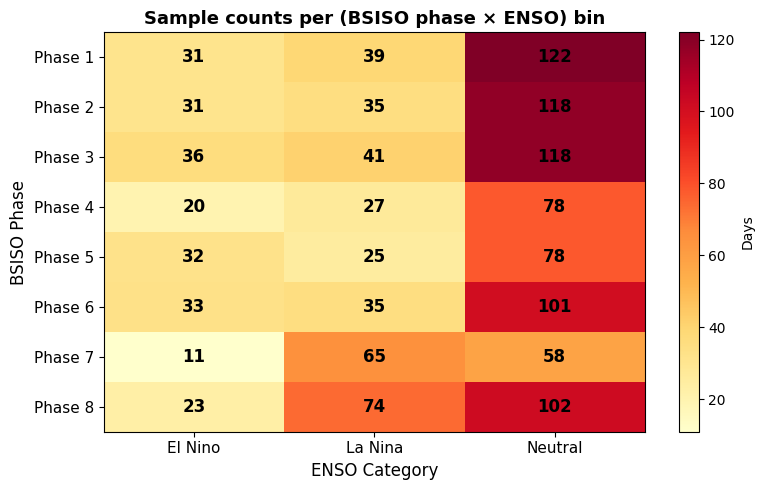

Plot saved!


In [20]:
import matplotlib.pyplot as plt

df = pd.read_csv(labels_path, parse_dates=['date'])

print('=' * 55)
print('LABELS VERIFICATION REPORT')
print('=' * 55)
print(f'Total MJJAS days:  {len(df)}')
print(f'Date range:        {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing values:    {df.isna().sum().sum()}')
print()

print('BSISO Phase distribution:')
for phase, count in df['bsiso_phase'].value_counts().sort_index().items():
    print(f'  Phase {phase}: {count} days')
print()

print('ENSO Category distribution:')
for cat, count in df['enso_category'].value_counts().items():
    print(f'  {cat}: {count} days ({count/len(df)*100:.1f}%)')
print()

print('Phase × ENSO sample counts (rows=phase, cols=ENSO):')
ct = pd.crosstab(df['bsiso_phase'], df['enso_category'])
print(ct)
print()
print('(These are the bins the model will learn from — check no bin is empty!)')
print()
print('=' * 55)
print('FILE ON GOOGLE DRIVE:')
mb = os.path.getsize(labels_path) / 1e6
print(f'  labels_mjjas.csv  ({mb:.2f} MB)')
print('=' * 55)

# Plot: phase × ENSO heatmap
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(ct.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(ct.columns)))
ax.set_yticks(range(len(ct.index)))
ax.set_xticklabels(ct.columns, fontsize=11)
ax.set_yticklabels([f'Phase {p}' for p in ct.index], fontsize=11)
ax.set_xlabel('ENSO Category', fontsize=12)
ax.set_ylabel('BSISO Phase', fontsize=12)
ax.set_title('Sample counts per (BSISO phase × ENSO) bin', fontsize=13, fontweight='bold')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, str(ct.values[i, j]), ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Days')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

---
## Done!

If all cells ran successfully you should have on your Google Drive:

```
BSISO_SSL_Project/
└── data/
    └── raw/
        ├── u850_v850_July_*.nc     ← from notebook 01
        ├── OLR_July_1979_2023.nc   ← from notebook 01
        ├── BSISO_INDEX.txt         ← manually downloaded from APEC
        ├── nino34_monthly.txt      ← auto-downloaded from NOAA
        └── labels.csv              ← produced by this notebook ✓
```

**Next step:** Run notebook `03_preprocessing.ipynb` to align ERA5 data with labels
and create the final input arrays for the model.

---
*DDCS Project | jh9141@nyu.edu*